In [1]:
# Part 1: Data Understanding & Preprocessing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [3]:
# Load the Wholesale Customers dataset

df = pd.read_csv(r"C:\Users\sudar\Documents\Collage\Placement prep\Machine learing and computer vison\Home Assignment\Home Assignment 3\Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
# Display number of observations and features

print("Number of observations:", df.shape[0])
print("Number of features:", df.shape[1])

Number of observations: 440
Number of features: 8


In [5]:
# Display data types of all columns

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [6]:
# Check for missing values

df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [7]:
# Display basic statistical summary

df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [8]:
# Categorical features

categorical_features = [
    "Channel",
    "Region"
]

# Numerical spending features

spending_features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

In [9]:
# Select the six spending attributes for unsupervised learning

X = df[spending_features]

X.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [10]:
# Compare variation among spending features

X.std().sort_values(ascending=False)

Fresh               12647.328865
Grocery              9503.162829
Milk                 7380.377175
Frozen               4854.673333
Detergents_Paper     4767.854448
Delicassen           2820.105937
dtype: float64

In [11]:
# Compare minimum and maximum values

X.agg(["min", "max"])

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
min,3,55,3,25,3,3
max,112151,73498,92780,60869,40827,47943


In [12]:
# Standardize the six spending features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
# Convert standardized data back to a DataFrame

X_scaled = pd.DataFrame(
    X_scaled,
    columns=spending_features
)

X_scaled.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


In [14]:
X_scaled.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,4.400000e+02,440.000000,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,-3.431598e-17,0.000000,-4.037175e-17,3.633457e-17,2.422305e-17,-8.074349e-18
std,1.001138e+00,1.001138,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-9.496831e-01,-0.778795,-8.373344e-01,-6.283430e-01,-6.044165e-01,-5.402644e-01
25%,-7.023339e-01,-0.578306,-6.108364e-01,-4.804306e-01,-5.511349e-01,-3.964005e-01
50%,-2.767602e-01,-0.294258,-3.366684e-01,-3.188045e-01,-4.336004e-01,-1.985766e-01
75%,3.905226e-01,0.189092,2.849105e-01,9.946441e-02,2.184822e-01,1.048598e-01
max,7.927738e+00,9.183650,8.936528e+00,1.191900e+01,7.967672e+00,1.647845e+01


In [15]:
print("Means after standardization:")
print(X_scaled.mean())

print("\nStandard deviations after standardization:")
print(X_scaled.std())

Means after standardization:
Fresh              -3.431598e-17
Milk                0.000000e+00
Grocery            -4.037175e-17
Frozen              3.633457e-17
Detergents_Paper    2.422305e-17
Delicassen         -8.074349e-18
dtype: float64

Standard deviations after standardization:
Fresh               1.001138
Milk                1.001138
Grocery             1.001138
Frozen              1.001138
Detergents_Paper    1.001138
Delicassen          1.001138
dtype: float64


In [16]:
scaler.fit_transform(X)

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       ...,
       [ 0.20032554,  1.31467078,  2.34838631, -0.54337975,  2.51121768,
         0.12145607],
       [-0.13538389, -0.51753572, -0.60251388, -0.41944059, -0.56977032,
         0.21304614],
       [-0.72930698, -0.5559243 , -0.57322717, -0.62009417, -0.50488752,
        -0.52286938]], shape=(440, 6))

In [17]:
# Correlation matrix

correlation_matrix = X.corr()

correlation_matrix

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368
Grocery,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497
Frozen,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947
Detergents_Paper,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291
Delicassen,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000


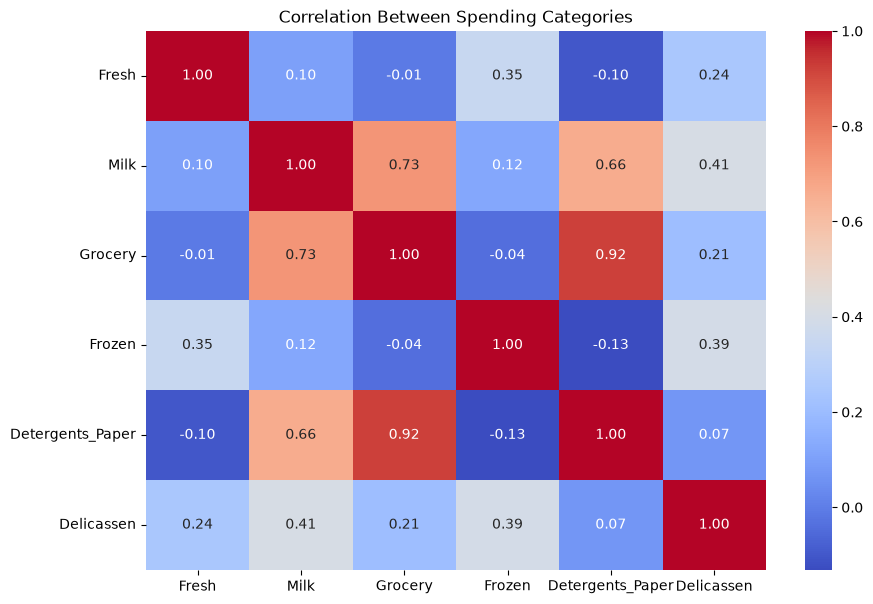

In [18]:
# Visualize correlations

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Spending Categories")
plt.show()

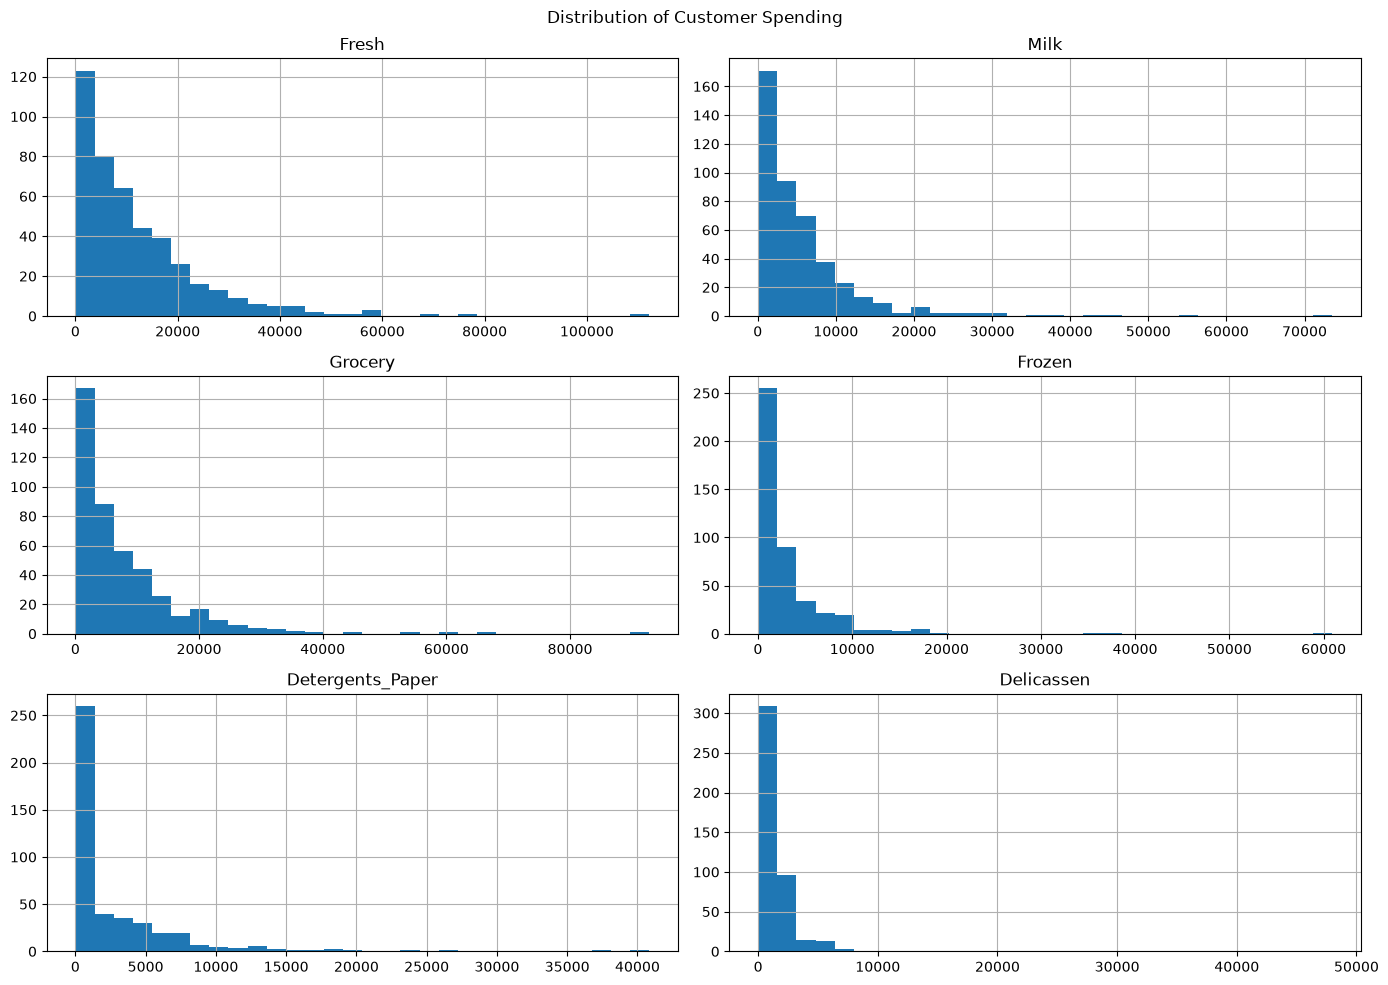

In [19]:
# Visualize distributions of spending features

X.hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Customer Spending")
plt.tight_layout()
plt.show()

### Q1. Variation in spending attributes
Fresh has the largest variation, followed by Grocery and Milk, based on their standard deviations. Delicassen has the lowest variation among the six spending categories.

### Q2. Are all six features on a comparable scale?
No
The ranges are clearly very different.

For example:
Fresh → 3 to 112151
Delicassen → 3 to 47943

If we used these raw values directly for a distance-based algorithm such as K-Means, large-scale features could have a disproportionate influence.

That's why we standardized the data.

### Q3. What could happen if clustering is performed without standardization?
Features with larger numerical scales and variation could dominate the distance calculations, causing the clustering algorithm to give them more influence than smaller-scale features.

### Q4. Which product categories appear to be correlated?
Customers who spend more on Grocery tend to also spend more on Detergents_Paper.
Correlation = 0.92

Milk ↔ Grocery has strong positive correlation. of 0.73...
Milk ↔ Detergents_Paper has 0.66


Other relationships are weaker. For example:
Fresh ↔ Grocery = -0.01...
Fresh ↔ Milk    = 0.10...
Fresh ↔ Detergents_Paper = -0.10



Grocery ↔ Detergents_Paper = 0.92

suggests that these two variables contain highly related information.

This will become interesting in PCA, because PCA is designed to find combinations of variables that explain the major patterns/variance in the data.